# Model Comparison — Option A vs Option B, 4 algorithms

Compares 8 model variants on the held-out 2024-25 test season:
- **Option A** — predict next-season OVR directly
- **Option B** — predict 8 underlying stats, then apply the OVR formula
- 4 algorithms: XGBoost, MLP (sklearn neural net), Autoencoder + KNN, Ensemble (XGB+MLP avg)

Run `python3 scripts/train_models.py` first to generate `outputs/predictions/test_predictions.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

preds = pd.read_csv('../outputs/predictions/test_predictions.csv')
model_cols = [c for c in preds.columns if c.startswith(('optA_', 'optB_'))]
actual = preds['actual_ovr']
print(f'{len(preds):,} test rows, {len(model_cols)} models')
preds.head()

292 test rows, 8 models


,Player,Season,next_Season,Age,actual_ovr,optA_xgboost,optA_mlp,optA_autoencoder,optA_ensemble,optB_xgboost,optB_mlp,optB_autoencoder,optB_ensemble
0,Aaron Gordon,2023,2024.0,27.0,83.0,74.199700,69.405673,77.87,71.802686,76.342205,44.903160,82.147935,63.876107
1,Aaron Holiday,2023,2024.0,26.0,56.8,45.432460,41.885287,47.88,43.658874,32.382971,42.827923,32.721392,33.147684
2,Aaron Nesmith,2023,2024.0,23.0,69.5,47.138470,46.065490,54.60,46.601980,38.510045,51.837802,43.333889,37.672496
3,Aaron Wiggins,2023,2024.0,24.0,73.7,50.589210,46.362284,51.37,48.475747,41.355832,44.981084,40.469256,39.405615
4,Al Horford,2023,2024.0,36.0,74.1,56.731335,64.829728,67.78,60.780531,60.964862,37.305924,70.693159,47.612847


## 1. Metrics table

In [2]:
def metrics(actual_arr, pred_arr):
    err = pred_arr - actual_arr
    return pd.Series({
        'MAE':  np.mean(np.abs(err)),
        'RMSE': np.sqrt(np.mean(err ** 2)),
        'R^2':  1 - np.sum(err ** 2) / np.sum((actual_arr - actual_arr.mean()) ** 2),
    })

metrics_df = pd.DataFrame({m: metrics(actual, preds[m]) for m in model_cols}).T
metrics_df.index.name = 'model'
metrics_df.sort_values('MAE').round(3)

,MAE,RMSE,R^2
model,,,
optA_ensemble,10.167,12.870,0.528
optA_mlp,10.407,13.186,0.504
optA_xgboost,10.579,13.214,0.502
optA_autoencoder,11.228,13.933,0.447
optB_xgboost,11.447,14.556,0.396
optB_autoencoder,11.722,15.470,0.318
optB_ensemble,13.775,16.658,0.209
optB_mlp,19.795,23.821,-0.618


## 2. MAE bar chart

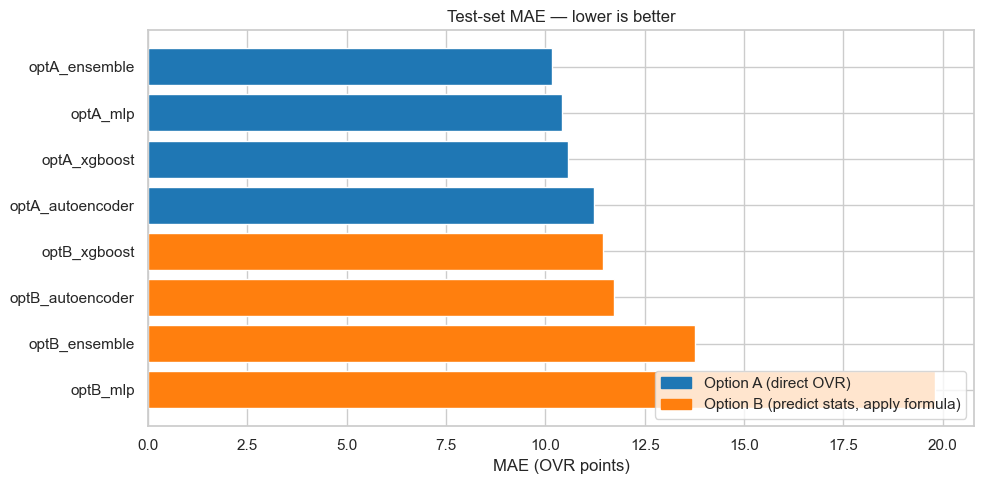

In [3]:
order = metrics_df['MAE'].sort_values().index
colors = ['#1f77b4' if m.startswith('optA_') else '#ff7f0e' for m in order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(order, metrics_df.loc[order, 'MAE'], color=colors)
ax.set_xlabel('MAE (OVR points)')
ax.set_title('Test-set MAE — lower is better')
ax.invert_yaxis()
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#1f77b4', label='Option A (direct OVR)'),
                   Patch(color='#ff7f0e', label='Option B (predict stats, apply formula)')], loc='lower right')
plt.tight_layout()
plt.show()

## 3. Predicted vs Actual scatter

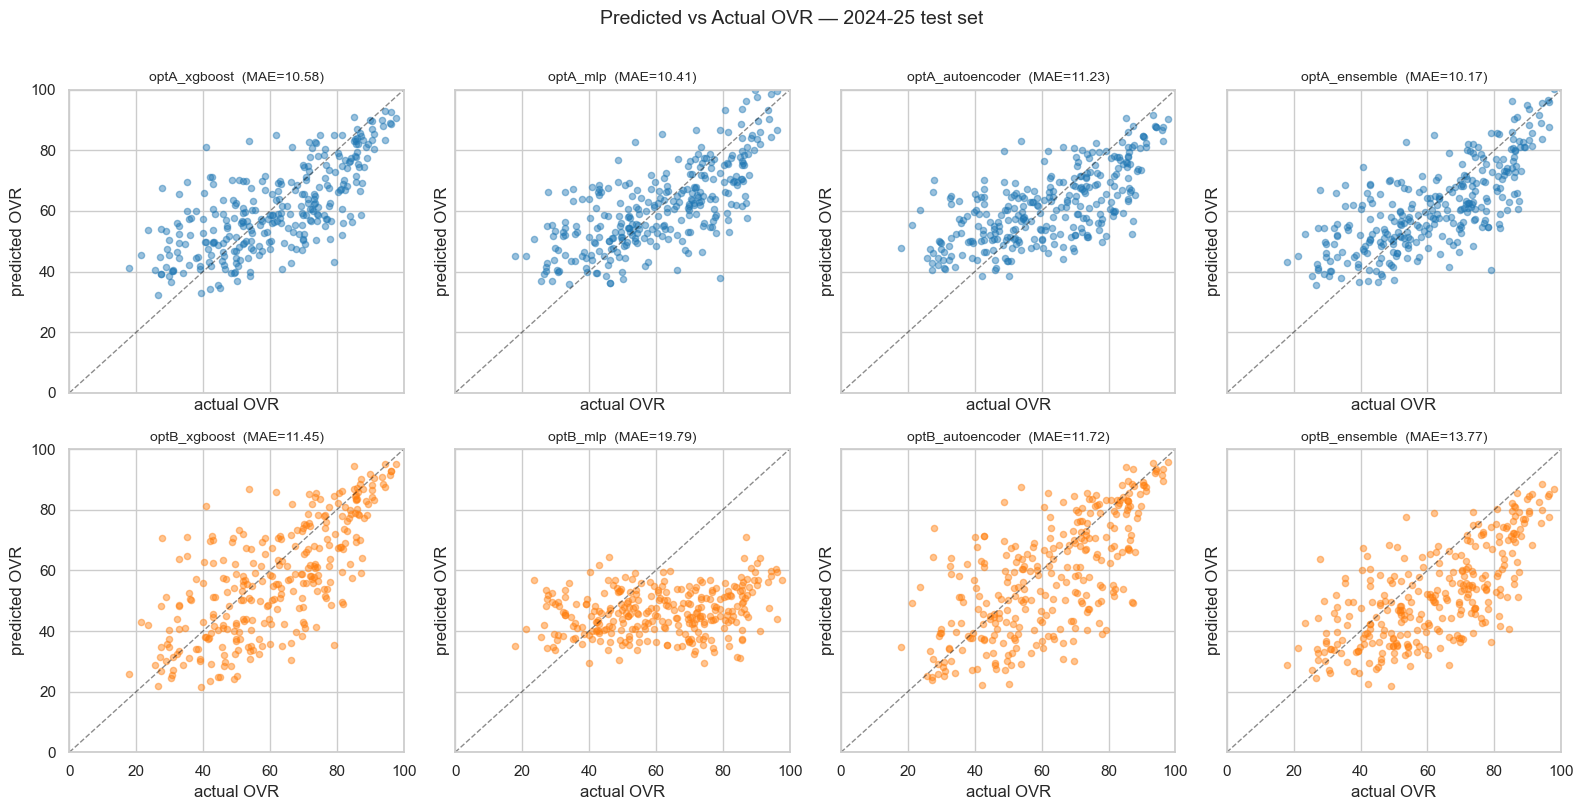

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
for ax, m in zip(axes.flat, model_cols):
    color = '#1f77b4' if m.startswith('optA_') else '#ff7f0e'
    ax.scatter(actual, preds[m], alpha=0.45, s=20, color=color)
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.5, lw=1)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_title(f"{m}  (MAE={metrics_df.loc[m, 'MAE']:.2f})", fontsize=10)
    ax.set_xlabel('actual OVR')
    ax.set_ylabel('predicted OVR')
fig.suptitle('Predicted vs Actual OVR — 2024-25 test set', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Residuals (predicted − actual) by actual OVR

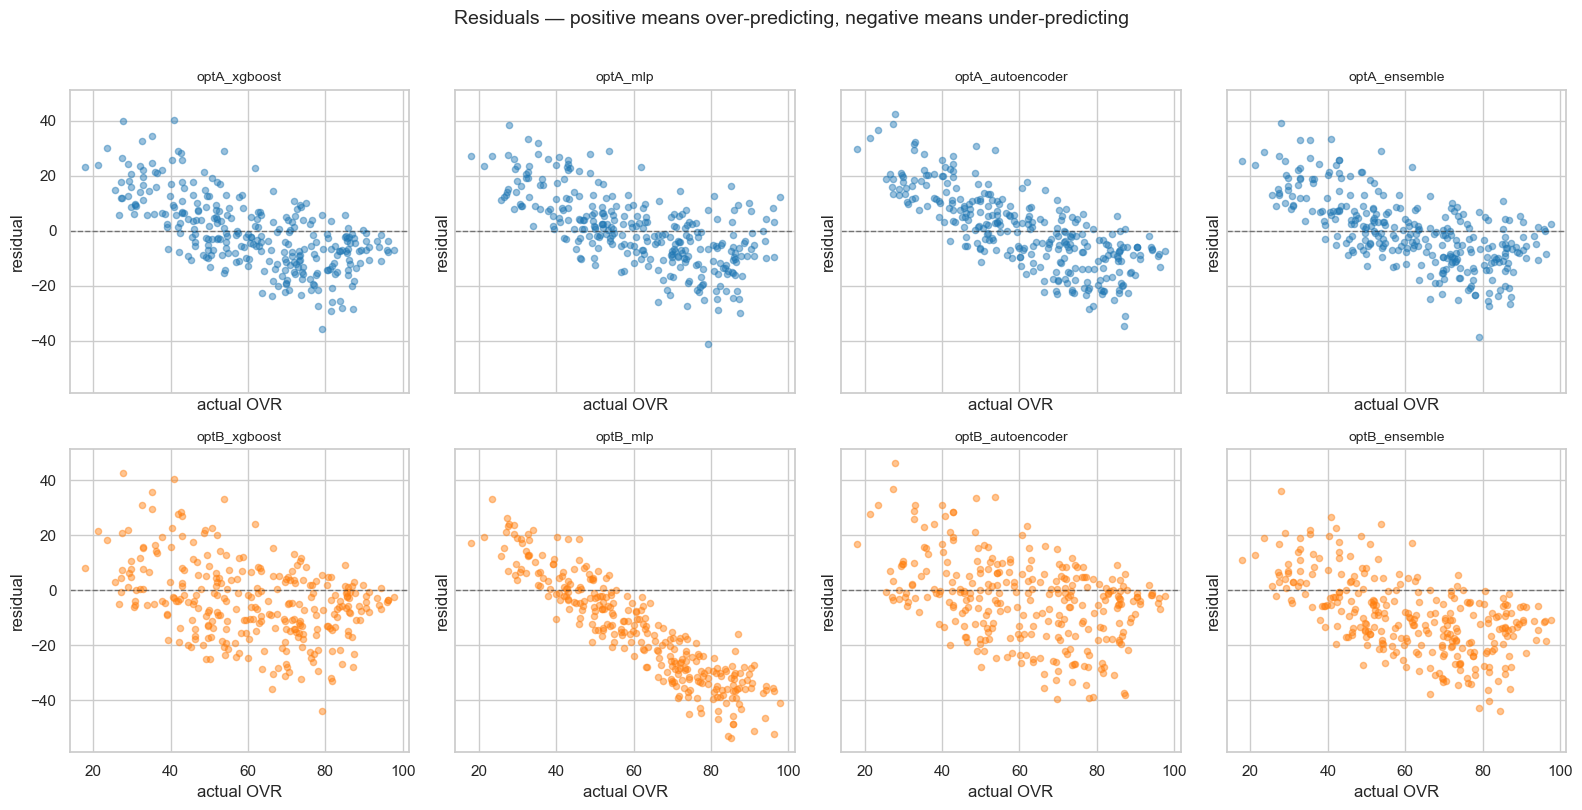

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
for ax, m in zip(axes.flat, model_cols):
    color = '#1f77b4' if m.startswith('optA_') else '#ff7f0e'
    resid = preds[m] - actual
    ax.scatter(actual, resid, alpha=0.45, s=20, color=color)
    ax.axhline(0, color='k', linestyle='--', alpha=0.5, lw=1)
    ax.set_title(m, fontsize=10)
    ax.set_xlabel('actual OVR'); ax.set_ylabel('residual')
fig.suptitle('Residuals — positive means over-predicting, negative means under-predicting', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Top-10 agreement

How many of each model's top-10 predicted players overlap with the actual top-10?

In [6]:
actual_top10 = set(preds.nlargest(10, 'actual_ovr')['Player'])
rows = []
for m in model_cols:
    pred_top10 = set(preds.nlargest(10, m)['Player'])
    rows.append({'model': m, 'overlap_with_actual_top10': len(actual_top10 & pred_top10)})

overlap_df = pd.DataFrame(rows).sort_values('overlap_with_actual_top10', ascending=False).reset_index(drop=True)
overlap_df

,model,overlap_with_actual_top10
0,optA_xgboost,7
1,optA_autoencoder,7
2,optB_xgboost,7
3,optB_autoencoder,7
4,optB_ensemble,6
5,optA_ensemble,5
6,optA_mlp,4
7,optB_mlp,3


## 6. Per-player example: notable players' predicted vs actual

In [7]:
notable = [
    'LeBron James', 'Nikola Jokić', 'Tyrese Haliburton', 'Anthony Edwards',
    'Luka Dončić', 'Jayson Tatum', 'Shai Gilgeous-Alexander', 'Stephen Curry',
]
sub = preds[preds['Player'].isin(notable)].copy()
show_cols = ['Player', 'Age', 'actual_ovr'] + model_cols
sub[show_cols].round(1).set_index('Player')

,Age,actual_ovr,optA_xgboost,optA_mlp,optA_autoencoder,optA_ensemble,optB_xgboost,optB_mlp,optB_autoencoder,optB_ensemble
Player,,,,,,,,,,
Anthony Edwards,21.0,88.6,81.3,84.1,73.3,82.7,82.7,60.8,77.2,77.0
Jayson Tatum,24.0,93.4,89.9,93.2,91.7,91.5,90.7,56.0,95.3,82.4
LeBron James,38.0,88.9,77.4,85.1,73.9,81.3,78.2,53.0,78.9,75.7
Luka Dončić,23.0,94.3,92.8,98.7,87.6,95.8,95.2,59.7,92.6,88.4
Nikola Jokić,27.0,97.7,90.7,110.0,90.5,100.4,95.2,56.7,95.7,86.8
Shai Gilgeous-Alexander,24.0,96.2,92.5,99.6,87.6,96.1,92.8,59.6,93.5,85.2
Stephen Curry,34.0,89.3,82.2,80.1,80.7,81.1,81.9,56.9,85.3,77.1
Tyrese Haliburton,22.0,90.4,89.6,97.7,84.7,93.6,88.2,62.3,89.3,84.6


## 7. Notable-player visual: each model's prediction vs actual

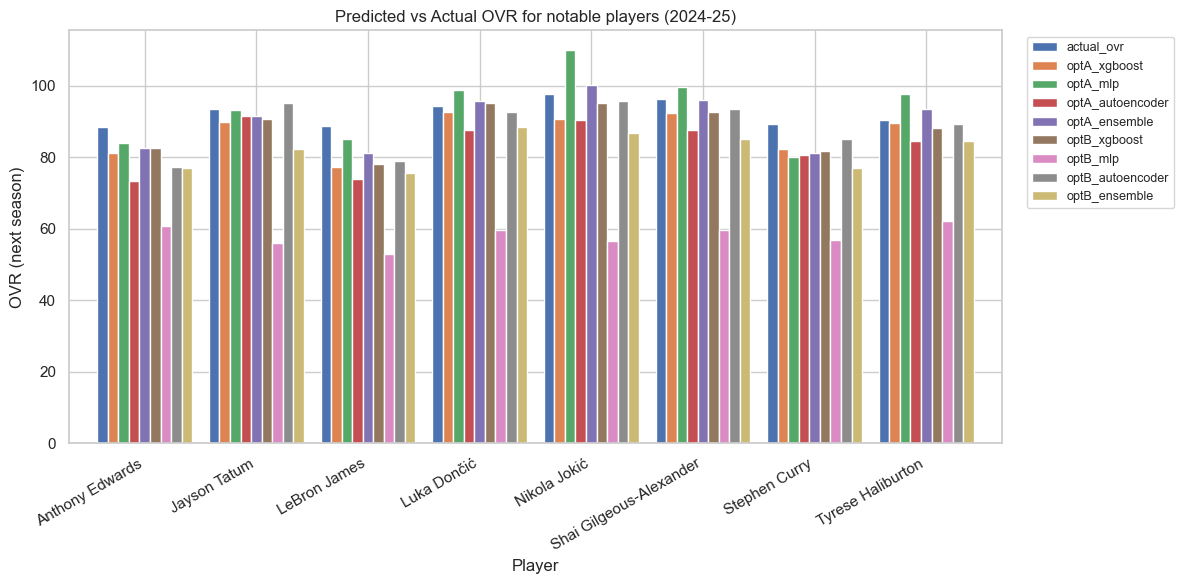

In [8]:
if len(sub) > 0:
    plot_df = sub.set_index('Player')[['actual_ovr'] + model_cols]
    fig, ax = plt.subplots(figsize=(12, 6))
    plot_df.plot(kind='bar', ax=ax, width=0.85)
    ax.set_ylabel('OVR (next season)')
    ax.set_title('Predicted vs Actual OVR for notable players (2024-25)')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('None of the listed notable players appeared in the test set (check accents and spelling).')

## 8. Verdict

Read off the metrics table at the top:

- **Best overall:** the row with the lowest MAE.
- **Option A vs Option B:** the comparison shows whether direct prediction or stat-then-formula wins. Usually direct is easier; stat-then-formula compounds 8 model errors.
- **Deep learning vs trees:** if XGBoost beats MLP / Autoencoder, the dataset is too small for deep learning to shine. That is a real result, not a failure.
- **Ensemble lift:** if `ensemble` MAE < min(`xgb`, `mlp`), the ensemble adds value; if not, it is averaging in a weaker model.